<a href="https://colab.research.google.com/github/kaansoftware34/softito_calismalar_face2face/blob/main/ata_s%C3%B6zleri_word2vec_%C3%B6rne%C4%9Fi_110626v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import math
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
d0 = "Damlaya damlaya göl olur."
d1 = "Sakla samanı, gelir zamanı."
d2 = "Gülü seven dikenine katlanır."
d3 = "Ağaç yaşken eğilir."
d4 = "Ak akçe kara gün içindir."
d5 = "Bir elin nesi var, iki elin sesi var."
d6 = "Tatlı dil yılanı deliğinden çıkarır."
d7 = "Rüzgar eken fırtına biçer."
d8 = "Komşu komşunun külüne muhtaçtır."
d9 = "Meyve veren ağacı taşlarlar."
d10 = "Ne doğrarsan aşına, o çıkar kaşığına."
string = [d0, d1, d2, d3, d4, d5, d6, d7, d8, d9, d10]


In [ ]:
import re

def tokenize(text):
    # Explicitly handle Turkish uppercase 'İ' and 'I' before lowercasing
    # Then normalize '’' to standard '''
    text = text.replace('İ', 'i').replace('I', 'ı').lower().replace('’', "'")

    # Split by whitespace first to handle spaces between words
    raw_words = text.split()

    cleaned_words = []
    # Pattern to find only valid word characters (including Turkish and apostrophe)
    # This ensures that punctuation attached to words is removed, and words are kept whole.
    word_char_pattern = re.compile(r"[a-zçğışöüâîû']+")

    for word in raw_words:
        # Extract valid word sequences from each raw word
        matches = word_char_pattern.findall(word)
        for match in matches:
            # Filter out single-character words (length > 1)
            if len(match) > 1:
                cleaned_words.append(match)
    return cleaned_words

tokenize_korpus = [tokenize(doc) for doc in string]
kelimeler = sorted(list(set([word for sublist in tokenize_korpus for word in sublist])))
kelime_idx = {w: i for i, w in enumerate(kelimeler)}
idx_kelime = {i: w for w, i in kelime_idx.items()}
V = len(kelimeler)

print(f"Kelime dağarcığı boyutu (V): {V}")
print(f"Kelimeler: {kelimeler}")

Kelime dağarcığı boyutu (V): 47
Kelimeler: ['ak', 'akçe', 'ağacı', 'ağaç', 'aşına', 'bir', 'biçer', 'damlaya', 'deliğinden', 'dikenine', 'dil', 'doğrarsan', 'eken', 'elin', 'eğilir', 'fırtına', 'gelir', 'göl', 'gülü', 'gün', 'iki', 'içindir', 'kara', 'katlanır', 'kaşığına', 'komşu', 'komşunun', 'külüne', 'meyve', 'muhtaçtır', 'ne', 'nesi', 'olur', 'rüzgar', 'sakla', 'samanı', 'sesi', 'seven', 'tatlı', 'taşlarlar', 'var', 'veren', 'yaşken', 'yılanı', 'zamanı', 'çıkar', 'çıkarır']


In [ ]:
# Komşu (context) kelimeleri çıkarma
def get_context_pairs(tokenize_korpus, window_size=2):
    pairs = []
    for doc in tokenize_korpus:
        for i, hedef in enumerate(doc):
            # Pencere içindeki komşular
            bas = max(0, i - window_size)
            son = min(len(doc), i + window_size + 1)
            for j in range(bas, son):
                if i != j:
                    pairs.append((hedef, doc[j]))
    return pairs

context_pairs = get_context_pairs(tokenize_korpus, window_size=2)
print(f"Toplam (hedef, komşu) çifti: {len(context_pairs)}")
print("İlk 10 çift:")
for pair in context_pairs[:10]:
    print(f"  '{pair[0]}' -> '{pair[1]}'")

Toplam (hedef, komşu) çifti: 134
İlk 10 çift:
  'damlaya' -> 'damlaya'
  'damlaya' -> 'göl'
  'damlaya' -> 'damlaya'
  'damlaya' -> 'göl'
  'damlaya' -> 'olur'
  'göl' -> 'damlaya'
  'göl' -> 'damlaya'
  'göl' -> 'olur'
  'olur' -> 'damlaya'
  'olur' -> 'göl'


Birlikte Oluşum Matrisi (ilk 10 kelime):


,ak,akçe,ağacı,ağaç,aşına,bir,biçer,damlaya,deliğinden,dikenine
ak,0,1,0,0,0,0,0,0,0,0
akçe,1,0,0,0,0,0,0,0,0,0
ağacı,0,0,0,0,0,0,0,0,0,0
ağaç,0,0,0,0,0,0,0,0,0,0
aşına,0,0,0,0,0,0,0,0,0,0
bir,0,0,0,0,0,0,0,0,0,0
biçer,0,0,0,0,0,0,0,0,0,0
damlaya,0,0,0,0,0,0,0,2,0,0
deliğinden,0,0,0,0,0,0,0,0,0,0
dikenine,0,0,0,0,0,0,0,0,0,0


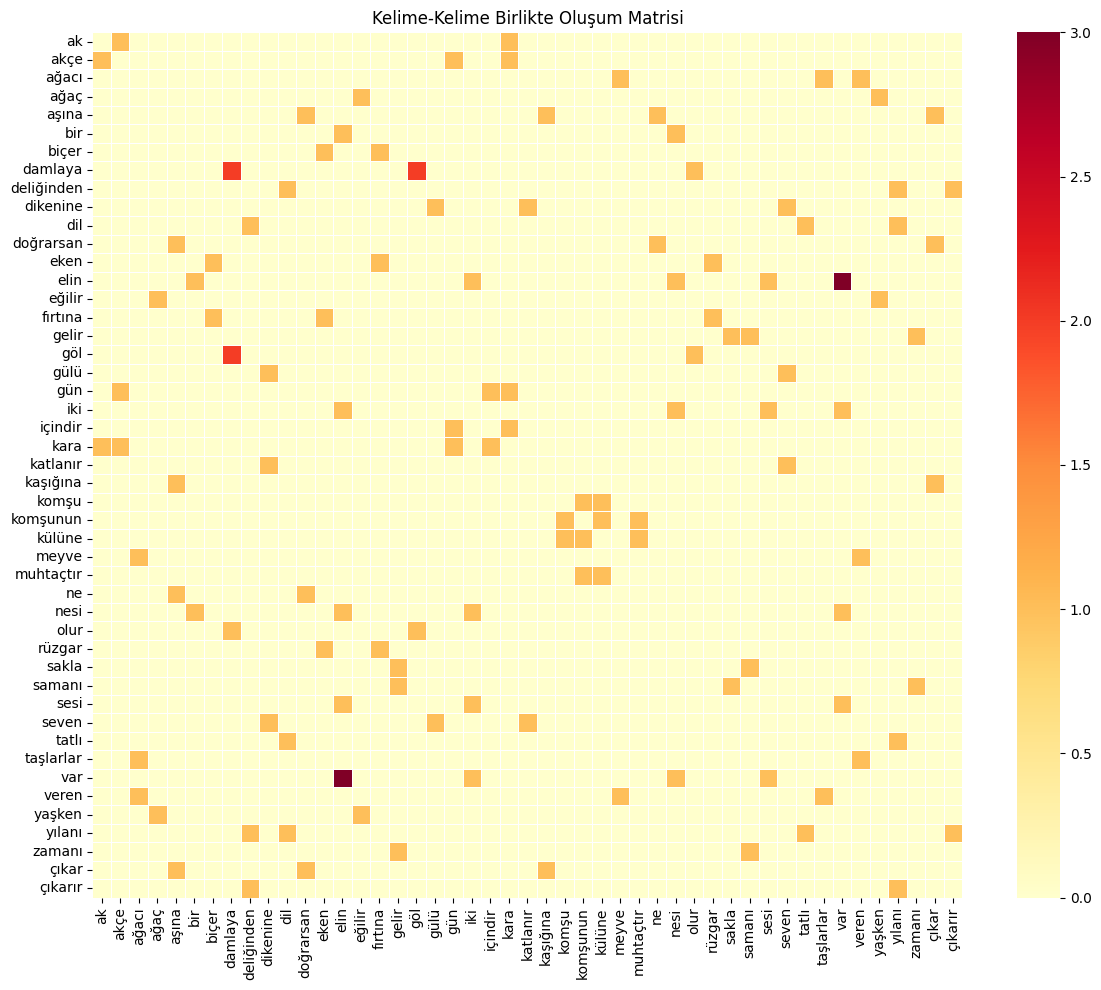

In [ ]:
# Birlikte oluşum matrisi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

cooc = np.zeros((V, V), dtype=int)
for hedef, komşu in context_pairs:
    i, j = kelime_idx[hedef], kelime_idx[komşu]
    cooc[i, j] += 1

df_cooc = pd.DataFrame(cooc, index=kelimeler, columns=kelimeler)
print("Birlikte Oluşum Matrisi (ilk 10 kelime):")
display(df_cooc.iloc[:10, :10])

# Görselleştirme: Isı haritası

plt.figure(figsize=(12, 10))
sns.heatmap(df_cooc, cmap="YlOrRd", annot=False if V < 15 else False, fmt="d", linewidths=0.5)
plt.title("Kelime-Kelime Birlikte Oluşum Matrisi")
plt.tight_layout()
plt.show()